In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import warnings
import matplotlib.pyplot as plt
import numpy as np
import glob
import xarray as xr
import xbudget
import regionate
import xwmt
import xwmb
import xgcm
import cartopy.crs as ccrs
import CM4Xutils #needed to run pip install nc-time-axis
from regionate import MaskRegions, GriddedRegion

In [3]:
print('xgcm version', xgcm.__version__, '\nregionate version', regionate.__version__, '\nxwmt version', xwmt.__version__, '\nxwmb version', xwmb.__version__)

xgcm version 0.9.1.dev6+gc9d4302b1 
regionate version 0.5.1 
xwmt version 0.1.0 
xwmb version 0.5.0


### Request HPC Resources

In [4]:
from dask_jobqueue import SLURMCluster  # setup dask cluster 
from dask.distributed import Client

log_directory="/vortexfs1/home/anthony.meza/scratch/notebooks/logs"

cluster = SLURMCluster(
    cores=36,
    processes=1,
    memory='190GB',
    walltime='04:00:00',
    queue='compute',
    interface='ib0', 
log_directory = log_directory)
print(cluster.job_script())
cluster.scale(jobs=6)

client = Client(cluster)
client

#!/usr/bin/env bash

#SBATCH -J dask-worker
#SBATCH -e /vortexfs1/home/anthony.meza/scratch/notebooks/logs/dask-worker-%J.err
#SBATCH -o /vortexfs1/home/anthony.meza/scratch/notebooks/logs/dask-worker-%J.out
#SBATCH -p compute
#SBATCH -n 1
#SBATCH --cpus-per-task=36
#SBATCH --mem=177G
#SBATCH -t 04:00:00

/vortexfs1/home/anthony.meza/miniforge3/envs/cm4x_chapter2/bin/python -m distributed.cli.dask_worker tcp://172.16.3.92:34078 --name dummy-name --nthreads 36 --memory-limit 176.95GiB --nanny --death-timeout 60 --interface ib0



Connection method: Cluster object,Cluster type: dask_jobqueue.SLURMCluster
Dashboard: /proxy/8787/status,
Dashboard: /proxy/8787/status,Workers: 0
Total threads: 0,Total memory: 0 B
Comm: tcp://172.16.3.92:34078,Workers: 0
Dashboard: /proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B


2026-05-14 13:04:21,205 - tornado.application - ERROR - Uncaught exception GET /individual-task-stream/ws (127.0.0.1)
HTTPServerRequest(protocol='http', host='127.0.0.1:8729', method='GET', uri='/individual-task-stream/ws', version='HTTP/1.1', remote_ip='127.0.0.1')
Traceback (most recent call last):
  File "/vortexfs1/home/anthony.meza/miniforge3/envs/cm4x_chapter2/lib/python3.11/site-packages/tornado/websocket.py", line 965, in _accept_connection
    open_result = handler.open(*handler.open_args, **handler.open_kwargs)
                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/vortexfs1/home/anthony.meza/miniforge3/envs/cm4x_chapter2/lib/python3.11/site-packages/tornado/web.py", line 3388, in wrapper
    return method(self, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/vortexfs1/home/anthony.meza/miniforge3/envs/cm4x_chapter2/lib/python3.11/site-packages/bokeh/server/views/ws.py", line 149, in open
    raise ProtocolError("Token is expired

### Load in data

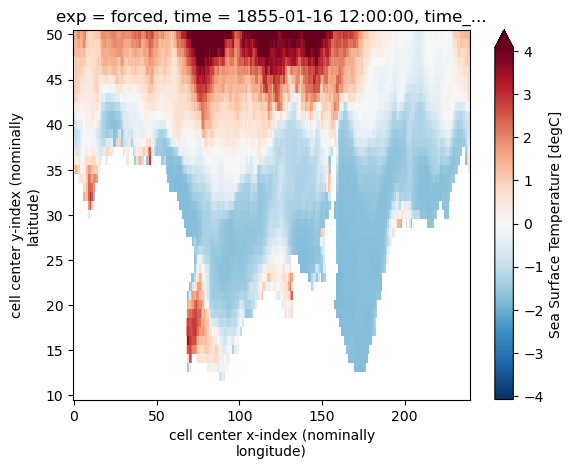

In [8]:
from tqdm import tqdm

datadir = lambda x="" : "/vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/data/model/budget_sigma2_v1.2.0/" + x
datafiles = glob.glob(datadir("CM4Xp125*"))[20:]
datafiles = sorted(datafiles)
datafiles

ds = xr.open_mfdataset(
        datafiles[1],
        data_vars="minimal",
        coords="minimal",
        compat="override",
        parallel=True,
        engine="zarr")

ds.sel(yh = slice(10, 50)).tos.isel(time = 0, exp = 0).plot(robust = True)

In [12]:
from tqdm import tqdm

datadir = lambda x="" : "/vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/data/model/budget_sigma2_v1.2.0/" + x
datafiles = glob.glob(datadir("CM4Xp125*"))[20:]
datafiles = sorted(datafiles)

dss = []

for (t, file) in enumerate(tqdm(datafiles)): 
    ds = xr.open_mfdataset(
        file,
        data_vars="minimal",
        coords="minimal",
        compat="override",
        parallel=True,
        engine="zarr")

    ds_sfc = ds[["fsitherm", "tos", "zos", "sos", "hfsso", "siconc", "taux", "tauy", "sithick"]] #select variables of interest 
    ds_sfc = ds_sfc.sel(yh = slice(10, 50))
    # ds_sfc = ds_sfc.groupby("time.year").mean("time") #use yearly data 
    dss += [1 * ds_sfc]

100%|██████████| 50/50 [00:20<00:00,  2.43it/s]


In [13]:
dss_ds = xr.concat(dss, dim = "time", combine_attrs="override")

dataset_size_bytes = dss_ds.nbytes
dataset_size_gb = dataset_size_bytes / (1024**3)
print(f"Dataset size: {dataset_size_gb:.2f} GB")

Dataset size: 69.94 GB


In [16]:
savedir = "/vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/data/model/"
dss_ds.to_zarr(savedir + f"Southern_Ocean_50S_Monthly_Surface_Fluxes_And_Properties.zarr", compute = True, mode = "w")

/vortexfs1/home/anthony.meza/miniforge3/envs/cm4x_chapter2/lib/python3.11/site-packages/zarr/api/asynchronous.py:247: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(
